# 09 — tSZ Cluster Stacking

**Purpose:** Compare tSZ cluster profiles between Agora and DDPM samples using a
signal-to-noise–based stacking approach.

This notebook identifies cluster locations by SNR thresholding, stacks cutouts from
both Agora and DDPM maps, and computes radial profiles to quantify agreement:

1. **SNR selection** — pixels satisfying A·σ < |T − T̄| ≤ B·σ are selected in three
   bins: (a) 5–10σ (~263k Agora clusters), (b) 10–20σ (~60k), (c) ≥20σ (~3.9k).

2. **Cutout extraction** — extracts 22×22 pixel (≈31') cutouts centred on each selected
   pixel from both the Agora and DDPM tSZ maps.

3. **Stacking** — uniformly weighted average of all cutouts per SNR bin, producing a
   mean cluster profile image Ŝ(θx, θy).

4. **Radial profiles** — converts the 2D stacked images to 1D profiles using
   `radial_profile`, with 10 linearly spaced bins of Δθ = 1' out to θ_max = 10'.
   Plots the profile, Agora–DDPM difference, and their ratio.

**Inputs:**
- Test maps and DDPM samples: `data/low_pass/2mJy/*.npy`

**Outputs:**
- Stacked cutout arrays: `tsz_extracts/agora_tsz_stacks.npy`,
  `tsz_extracts/ddpm_tsz_stacks.npy`
- Radial profile plots: `plots/tsz_stacks.pdf`,
  `plots/tsz_stacks_radial_profile.pdf` (Figure 3)

**Key module functions:**
- `foregrounds_diffusion.flatmaps.radial_profile`

**Paper reference:** §4.2 (Figure 3 — stacked tSZ radial profiles in three SNR bins).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from foregrounds_diffusion.flatmaps import radial_profile
from foregrounds_diffusion.preprocessing import renormalize_dm_maps

PTSRC      = 2
CUTOUT_PIX = 22       # 22 px × 1.41 arcmin/px ≈ 31 arcmin
PIXEL_RES  = 1.41     # arcmin / pixel

SNR_BINS = [
    (5,  10,  "5–10σ"),
    (10, 20,  "10–20σ"),
    (20, None, "≥20σ"),
]

PROJECT_ROOT = Path("/home/apb86/cmb_foregrounds_diffusion")
PATCHES_DIR = Path(f"data/low_pass/{PTSRC}mJy")

OUT_DIR = Path("tsz_extracts")
OUT_DIR.mkdir(exist_ok=True)


In [7]:
cib_maps    = np.load(PATCHES_DIR / f"CIB_map_150GHz_256_st6_minmax_{PTSRC}mJy_zero_lp.npy")
tsz_maps    = np.load(PATCHES_DIR / f"tSZ3_map_150GHz_256_st6_minmax_{PTSRC}mJy_norm_lp.npy")
ddpm_raw    = np.load(PROJECT_ROOT / "data" / "low_pass" / f"{PTSRC}mJy" / f"new_samples_cib_tsz_{PTSRC}mJy_zero_norm_6x6_w_au_lp.npy")
gauss_maps  = np.load(PATCHES_DIR / f"gaussian_cib_tsz_{PTSRC}mJy_lp.npy")

# Collect pixel values from N_SAMPLES maps per source
agora_cib_px  = cib_maps[:, :, :, 0].ravel()
agora_tsz_px  = tsz_maps[:, :, :, 0].ravel()

train_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)  # (N, H, W, 2)
print(f"train_maps shape: {train_maps.shape}")
print(f"ddpm_raw shape:   {ddpm_raw.shape}")

ddpm_renorm = renormalize_dm_maps(ddpm_raw, train_maps, variance_scaling=True)

agora_tsz = tsz_maps[:, :, :, 0]   # (N, H, W)
ddpm_tsz  = ddpm_renorm[:, 1]         # (N, H, W)
print(f"Agora tSZ maps: {agora_tsz.shape},  DDPM tSZ maps: {ddpm_tsz.shape}")


train_maps shape: (674, 256, 256, 2)
ddpm_raw shape:   (640, 2, 256, 256)
Agora tSZ maps: (674, 256, 256),  DDPM tSZ maps: (640, 256, 256)


In [12]:
from scipy.ndimage import maximum_filter

def select_snr_pixels(tsz_maps_nhw, snr_min, snr_max, min_separation=5):
    """Find (patch_idx, row, col) of local SNR peaks within a bin.
    
    Parameters
    ----------
    tsz_maps_nhw : ndarray, shape (N, H, W)
        Stack of tSZ patches.
    snr_min, snr_max : float
        SNR bin edges (snr_max=None for open-ended upper bound).
    min_separation : int
        Minimum pixel separation between peaks.
    """
    coords = []
    for i, m in enumerate(tsz_maps_nhw):
        noise = m.std()
        if noise == 0:
            continue
        snr_map = m / noise
        local_max = maximum_filter(snr_map, size=min_separation) == snr_map
        in_bin = (snr_map >= snr_min) & local_max
        if snr_max is not None:
            in_bin &= (snr_map < snr_max)
        for ri, rj in np.argwhere(in_bin):
            coords.append((i, ri, rj))
    print(f"SNR [{snr_min}, {snr_max}): {len(coords)} peaks found")
    return coords


def extract_cutouts(maps_nhw, coords, cutout_size, max_cutouts=500):
    """Extract cutouts around (patch_idx, row, col) coords."""
    half = cutout_size // 2
    cutouts = []
    for patch_idx, ri, rj in coords[:max_cutouts]:
        m = maps_nhw[patch_idx]
        ri0, ri1 = ri - half, ri + half
        rj0, rj1 = rj - half, rj + half
        if ri0 < 0 or ri1 > m.shape[0] or rj0 < 0 or rj1 > m.shape[1]:
            continue
        cutouts.append(m[ri0:ri1, rj0:rj1])
    return np.array(cutouts, dtype=np.float32) if cutouts else None


for smin, smax, label in SNR_BINS:
    coords = select_snr_pixels(agora_tsz, smin, smax)
    a_cuts = extract_cutouts(agora_tsz, coords, CUTOUT_PIX)
    d_cuts = extract_cutouts(ddpm_tsz,  coords, CUTOUT_PIX)
    agora_stacks[label] = a_cuts.mean(axis=0) if a_cuts is not None else None
    ddpm_stacks[label]  = d_cuts.mean(axis=0) if d_cuts is not None else None
    print(f"{label}: stacked {len(a_cuts) if a_cuts is not None else 0} Agora / "
          f"{len(d_cuts) if d_cuts is not None else 0} DDPM cutouts")

np.save(OUT_DIR / "agora_tsz_stacks.npy", {k: v for k, v in agora_stacks.items()}, allow_pickle=True)
np.save(OUT_DIR / "ddpm_tsz_stacks.npy",  {k: v for k, v in ddpm_stacks.items()},  allow_pickle=True)

SNR [5, 10): 17985 peaks found
5–10σ: stacked 402 Agora / 402 DDPM cutouts
SNR [10, 20): 3051 peaks found
10–20σ: stacked 402 Agora / 402 DDPM cutouts
SNR [20, None): 70 peaks found
≥20σ: stacked 53 Agora / 53 DDPM cutouts


In [9]:
"""
def extract_cutouts(maps_nhw, pixel_coords, cutout_size, max_cutouts=500):
    """Extract cutouts around pixel_coords from all maps."""
    half = cutout_size // 2
    cutouts = []
    coords = pixel_coords[:max_cutouts]  # cap to avoid memory issues
    for i, m in enumerate(maps_nhw):
        for (ri, rj) in coords:
            ri0, ri1 = ri - half, ri + half
            rj0, rj1 = rj - half, rj + half
            if ri0 < 0 or ri1 > m.shape[0] or rj0 < 0 or rj1 > m.shape[1]:
                continue
            cutouts.append(m[ri0:ri1, rj0:rj1])
    return np.array(cutouts, dtype=np.float32) if cutouts else None

agora_stacks, ddpm_stacks = {}, {}
for smin, smax, label in SNR_BINS:
    coords = select_snr_pixels(agora_tsz, smin, smax)
    a_cuts = extract_cutouts(agora_tsz, coords, CUTOUT_PIX)
    d_cuts = extract_cutouts(ddpm_tsz,  coords, CUTOUT_PIX)
    agora_stacks[label] = a_cuts.mean(axis=0) if a_cuts is not None else None
    ddpm_stacks[label]  = d_cuts.mean(axis=0) if d_cuts is not None else None
    n_a = len(a_cuts) if a_cuts is not None else 0
    n_d = len(d_cuts) if d_cuts is not None else 0
    print(f"{label}: stacked {n_a} Agora / {n_d} DDPM cutouts")

np.save(OUT_DIR / "agora_tsz_stacks.npy", {k: v for k, v in agora_stacks.items()}, allow_pickle=True)
np.save(OUT_DIR / "ddpm_tsz_stacks.npy",  {k: v for k, v in ddpm_stacks.items()},  allow_pickle=True)
"""

SNR [5, 10): 0 peaks found
5–10σ: stacked 0 Agora / 0 DDPM cutouts
SNR [10, 20): 0 peaks found
10–20σ: stacked 0 Agora / 0 DDPM cutouts
SNR [20, None): 0 peaks found
≥20σ: stacked 0 Agora / 0 DDPM cutouts


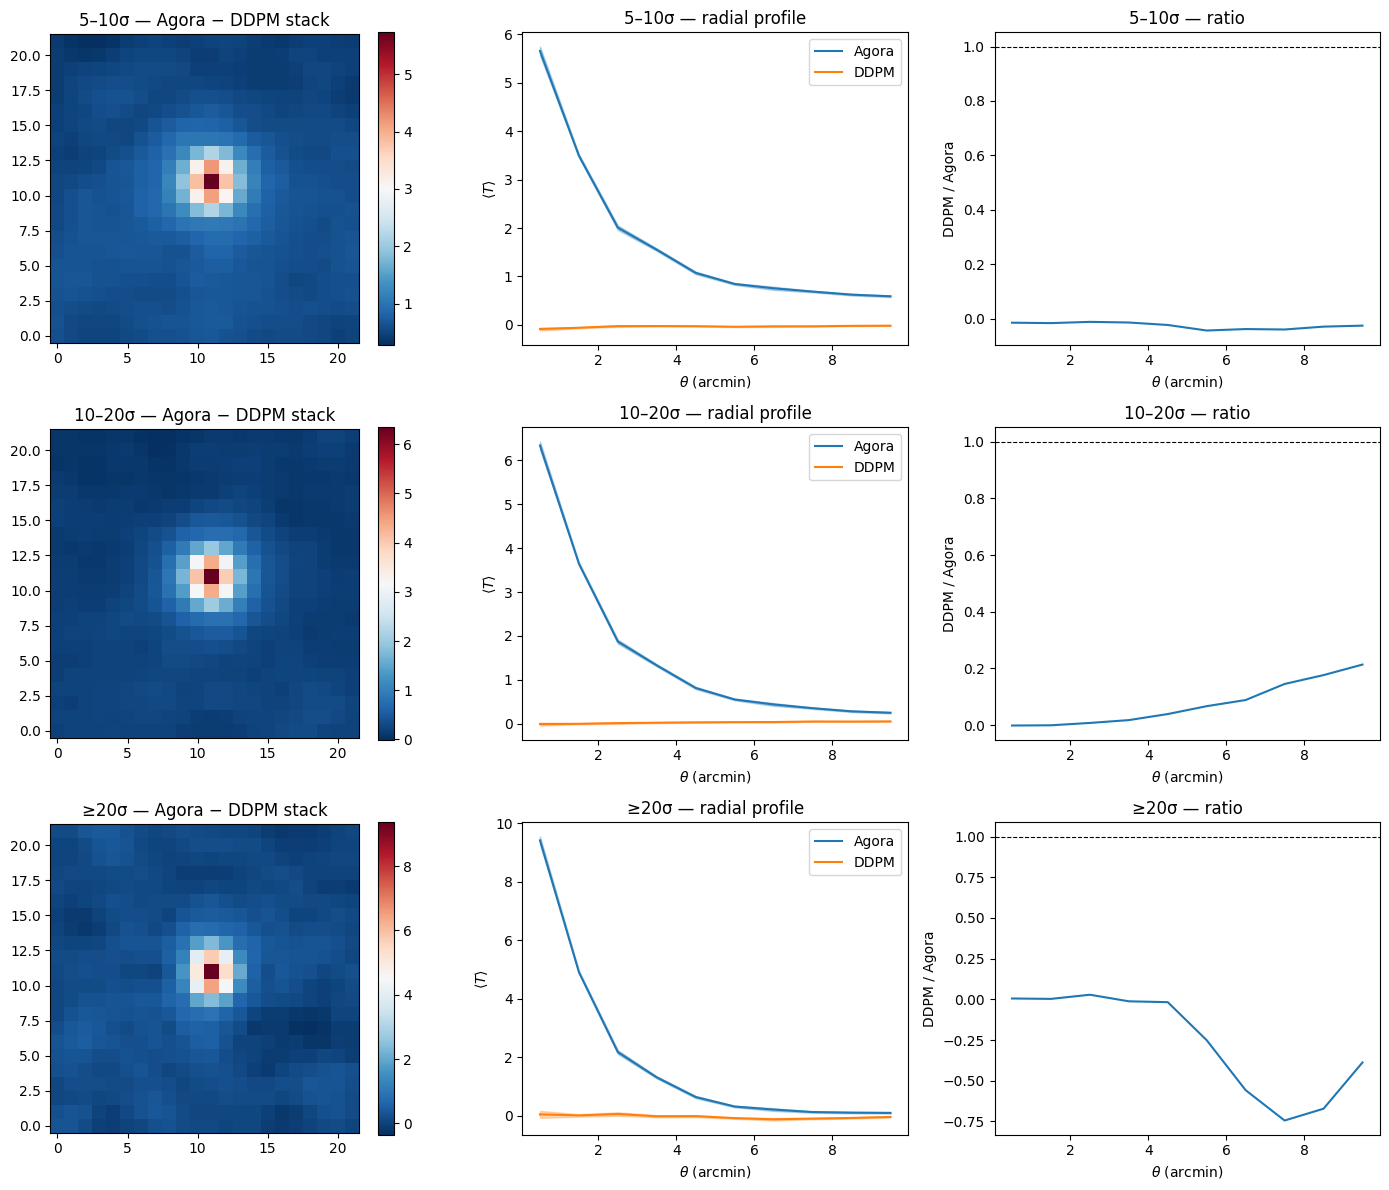

In [13]:
# Build coordinate grids (degrees) for the cutout
HALF    = CUTOUT_PIX // 2
pix_deg = PIXEL_RES / 60.
xi      = (np.arange(CUTOUT_PIX) - HALF) * pix_deg
xgrid, ygrid = np.meshgrid(xi, xi)

fig, axes = plt.subplots(len(SNR_BINS), 3, figsize=(14, 4 * len(SNR_BINS)))

for row, (smin, smax, label) in enumerate(SNR_BINS):
    a_stack = agora_stacks[label]
    d_stack = ddpm_stacks[label]
    if a_stack is None or d_stack is None:
        continue

    # Radial profiles: bin_size=1', maxbin=10', to_arcmins converts degrees→arcmin
    prof_a = radial_profile(a_stack, xy=(xgrid, ygrid), bin_size=1., minbin=0., maxbin=10., to_arcmins=1)
    prof_d = radial_profile(d_stack, xy=(xgrid, ygrid), bin_size=1., minbin=0., maxbin=10., to_arcmins=1)
    theta  = prof_a[:, 0]   # arcmin

    ax_img, ax_prof, ax_res = axes[row]

    im = ax_img.imshow(a_stack - d_stack, origin="lower", cmap="RdBu_r")
    ax_img.set_title(f"{label} — Agora − DDPM stack")
    plt.colorbar(im, ax=ax_img)

    ax_prof.plot(theta, prof_a[:, 1], label="Agora", color="C0")
    ax_prof.fill_between(theta, prof_a[:,1]-prof_a[:,2], prof_a[:,1]+prof_a[:,2], alpha=0.3, color="C0")
    ax_prof.plot(theta, prof_d[:, 1], label="DDPM",  color="C1")
    ax_prof.fill_between(theta, prof_d[:,1]-prof_d[:,2], prof_d[:,1]+prof_d[:,2], alpha=0.3, color="C1")
    ax_prof.set_xlabel(r"$\theta$ (arcmin)");  ax_prof.set_ylabel(r"$\langle T \rangle$")
    ax_prof.set_title(f"{label} — radial profile");  ax_prof.legend()

    ratio = prof_d[:, 1] / (prof_a[:, 1] + 1e-30)
    ax_res.plot(theta, ratio)
    ax_res.axhline(1., color="k", ls="--", lw=0.8)
    ax_res.set_xlabel(r"$\theta$ (arcmin)");  ax_res.set_ylabel("DDPM / Agora")
    ax_res.set_title(f"{label} — ratio")

plt.tight_layout()
Path("plots").mkdir(exist_ok=True)
plt.savefig("plots/tsz_stacks_radial_profile.pdf", bbox_inches="tight")
plt.show()
